# 00 — Feature Extraction + Interval-Stratified Detection Benchmark

End-to-end pipeline for extracting temporal C2-beaconing features from IoT-23, CTU-13, and TQH-C2, followed by interval-stratified detection and cross-corpus evaluation.

**Research objective:** measure whether C2-beacon detection degrades as beacon interval increases and evaluate whether models trained on IoT-23 transfer to CTU-13.

**Core design:** channel = `(src_ip → dst_ip)`; windowed inter-arrival-time features; minimum 4 flows per channel/window; bands B1 `< 60 s`, B2 `60–600 s`, B3 `≥ 600 s`; positive class = labeled C2 beaconing only.

**Main outputs:** `features.parquet`, benchmark metrics, per-band results/figures, SHAP attribution, and bootstrap confidence intervals.

## 1. Setup

Install dependencies and initialize the feature-extraction environment.

In [1]:
%pip install -q pandas pyarrow tqdm scipy scikit-learn imbalanced-learn matplotlib shap

import os, json, glob, re, gc, time, zipfile, warnings
import numpy as np
import pandas as pd
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x

WORK_DIR   = os.path.expanduser("~/c2_work")
OUTPUT_DIR = os.path.expanduser("~/c2_features_out")
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
for d in (WORK_DIR, OUTPUT_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

# Extraction parameters
MAX_SEQ_LEN   = 50
WINDOW_GRID   = [5, 15, 30, 60, 120]          # minutes; must match config.py WINDOWS_MIN
MIN_CONN      = 4                              # min flows in a window before a channel is emitted
GROUP_TS_CAP  = 200_000                        # safety cap on stored timestamps per channel
IOT23_CHUNKSIZE = 1_000_000                    # rows per streaming chunk

# Interval bands
BAND_EDGES_S  = (60.0, 600.0)
BAND_BINS     = [-np.inf, BAND_EDGES_S[0], BAND_EDGES_S[1], np.inf]
BAND_LABELS   = ["B1", "B2", "B3"]

print("Setup complete. pandas", pd.__version__)

Note: you may need to restart the kernel to use updated packages.
Setup complete. pandas 3.0.5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Dataset paths

IoT-23: `dataset*.csv` files.

CTU-13: scenario directories `1/`–`13/` containing raw `*.binetflow`.

TQH-C2: `A/`, `B/`, `C/` containing interval/jitter cells with `labeled.jsonl`.

CTU-13 extraction uses the raw Argus files because the exported feature files do not retain the required timestamp/address fields.

In [2]:
# Local dataset paths
IOT23_DIR = os.path.expanduser("~/Downloads/IOT-23")                          # dataset*.csv
CTU13_DIR = os.path.expanduser("~/Downloads/CTU-13-extract/CTU-13-Dataset")    # 1/../13/*.binetflow
TQHC2_DIR = os.path.expanduser("~/Downloads/TQH-C2_labels_v110")               # A/ B/ C/ cells

for name, p in [("IOT23_DIR", IOT23_DIR), ("CTU13_DIR", CTU13_DIR), ("TQHC2_DIR", TQHC2_DIR)]:
    print(f"{name:10} {p}   (exists: {os.path.isdir(p)})")

ctu13_df = iot23_df = tqhc2_df = pd.DataFrame()
print("\nPaths configured.")

IOT23_DIR  /Users/ador/Downloads/IOT-23   (exists: True)
CTU13_DIR  /Users/ador/Downloads/CTU-13-extract/CTU-13-Dataset   (exists: True)
TQHC2_DIR  /Users/ador/Downloads/TQH-C2_labels_v110   (exists: True)

Paths configured.


## 3. Shared feature functions

Compute temporal inter-arrival statistics and convert channel timestamp groups into windowed feature rows.

In [3]:
def compute_temporal_features(timestamps):
    ts = np.sort(np.asarray(timestamps, dtype=float))
    n = len(ts)
    if n < 2:
        return None
    deltas = np.diff(ts)
    mean_iat = float(np.mean(deltas))
    std_iat = float(np.std(deltas))
    cv_iat = std_iat / mean_iat if mean_iat > 0 else np.nan
    median_delta = float(np.median(deltas))
    mad = float(np.median(np.abs(deltas - median_delta)))
    jitter_ratio = mad / median_delta if median_delta > 0 else np.nan
    if n >= 4:
        q1, q2, q3 = np.percentile(deltas, [25, 50, 75])
        denom = (q3 - q1)
        bowley_skew = 0.0 if denom == 0 else float((q3 + q1 - 2 * q2) / denom)
    else:
        bowley_skew = np.nan
    if n >= 4 and np.std(deltas[:-1]) > 0 and np.std(deltas[1:]) > 0:
        with np.errstate(divide="ignore", invalid="ignore"):
            acf1 = float(np.corrcoef(deltas[:-1], deltas[1:])[0, 1])
        if not np.isfinite(acf1):
            acf1 = np.nan
    else:
        acf1 = np.nan
    return {
        "n_connections": n, "mean_iat": mean_iat, "median_iat": median_delta,
        "std_iat": std_iat, "cv_iat": cv_iat, "mad_iat": mad,
        "jitter_ratio": jitter_ratio, "bowley_skew": bowley_skew,
        "acf_lag1": acf1, "iat_sequence": deltas[:MAX_SEQ_LEN].tolist(),
    }


def records_from_groups(groups, meta, id_prefix, dataset_name, scenario,
                        interval_s, jitter_pct, window_grid=WINDOW_GRID):
    """groups: {channel_key: array/list of timestamps}
       meta:   {channel_key: {'label': int, 'detailed': str}}"""
    records = []
    for key, ts_list in groups.items():
        ts_sorted = np.sort(np.asarray(ts_list, dtype=float))
        if ts_sorted.size < MIN_CONN:
            continue
        m = meta[key]
        t0 = ts_sorted[0]
        for w in window_grid:
            feats = compute_temporal_features(ts_sorted[ts_sorted <= t0 + w * 60])
            if feats is None:
                continue
            records.append({
                "cell_id": f"{id_prefix}_w{w}", "dataset": dataset_name,
                "scenario": scenario, "interval_s": interval_s,
                "jitter_pct": jitter_pct, "window_min": w, "flow_id": str(key),
                "label": int(m["label"]), "detailed_label": m["detailed"], **feats,
            })
    return records


print("Feature functions defined.")

Feature functions defined.


## 4. CTU-13 — validation corpus

Parse raw Argus `*.binetflow` data.

The positive class is restricted to documented C&C-channel labels rather than all `From-Botnet` traffic. Other botnet activity is retained as `other-botnet` and excluded from the binary detection task.

Use the same temporal windowing and minimum-flow requirement as IoT-23.

In [4]:
CTU13_FAMILY = {"1": "Neris", "2": "Neris", "3": "Rbot", "4": "Rbot", "5": "Virut",
                "6": "Menti", "7": "Sogou", "8": "Murlo", "9": "Neris", "10": "Rbot",
                "11": "Rbot", "12": "NSIS.ay", "13": "Virut"}

binetflow_files = sorted(glob.glob(os.path.join(CTU13_DIR, "*", "*.binetflow")),
                         key=lambda p: os.path.getsize(p))
print(f"Found {len(binetflow_files)} .binetflow files under {CTU13_DIR}")
if binetflow_files:
    with open(binetflow_files[0]) as f:
        print("header:", f.readline().strip())

Found 13 .binetflow files under /Users/ador/Downloads/CTU-13-extract/CTU-13-Dataset
header: StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label


### 4a. CTU-13 label taxonomy

Inspect the raw label taxonomy across all 13 scenarios and identify the labels matching the C&C-channel marker used by the parser.

In [5]:
# Inspect raw CTU-13 labels
from collections import Counter

label_samples = Counter()
for fp in binetflow_files:
    scen = os.path.basename(os.path.dirname(fp))
    try:
        # only the Label column, only enough rows to see the taxonomy -- this
        # is a peek, not a full pass (the real parse happens in the next cell)
        head = pd.read_csv(fp, usecols=["Label"], dtype=str, nrows=200_000)
    except Exception as e:
        print(f"[SKIP inspect] {scen}: {e}"); continue
    vc = head["Label"].value_counts()
    print(f"\n=== scenario {scen} -- top labels (first 200k rows) ===")
    print(vc.head(15).to_string())
    for lab in vc.index:
        label_samples[lab] += 1

print(f"\n\n{len(label_samples)} distinct label strings seen across scenarios (first 200k rows each).")
print("A C&C-channel marker ('-CC' + digit segment, e.g. '-CC4-HTTP-') appears")
print("within From-Botnet labels in the scenarios listed above.")


=== scenario 11 -- top labels (first 200k rows) ===
Label
flow=Background-UDP-Established           37342
flow=To-Background-UDP-CVUT-DNS-Server    30568
flow=Background-TCP-Established            9363
flow=Background-Established-cmpgw-CVUT     6981
flow=From-Botnet-V51-1-ICMP                4144
flow=From-Botnet-V51-2-ICMP                3999
flow=Background-Attempt-cmpgw-CVUT         3378
flow=Background                            3230
flow=From-Normal-V52-Grill                 2113
flow=Background-UDP-Attempt                1951
flow=Background-TCP-Attempt                1244
flow=To-Background-CVUT-Proxy               661
flow=From-Normal-V52-Stribrek               581
flow=Background-UDP-NTP-Established-1       287
flow=To-Background-CVUT-WebServer           162

=== scenario 7 -- top labels (first 200k rows) ===
Label
flow=To-Background-UDP-CVUT-DNS-Server    45799
flow=Background-UDP-Established           32659
flow=Background-TCP-Established           11821
flow=Background-Est

In [6]:
CTU13_USECOLS = ["StartTime", "SrcAddr", "DstAddr", "Label"]

# C&C marker used to separate command-channel flows from other botnet activity.
CTU13_CC_PATTERN = re.compile(r"-CC\d*-", re.IGNORECASE)


def parse_ctu13_binetflow(fpath, window_grid=WINDOW_GRID):
    scen_no  = os.path.basename(os.path.dirname(fpath))
    scenario = f"{scen_no}_{CTU13_FAMILY.get(scen_no, '?')}"
    t0 = time.time()
    parts, n_rows, n_kept = [], 0, 0
    try:
        reader = pd.read_csv(fpath, sep=",", usecols=CTU13_USECOLS, dtype=str,
                             low_memory=False, chunksize=IOT23_CHUNKSIZE)
    except Exception as e:
        print(f"[SKIP] ctu13 {scenario}: {e}"); return []
    for chunk in reader:
        n_rows += len(chunk)
        dt = pd.to_datetime(chunk["StartTime"], format="%Y/%m/%d %H:%M:%S.%f", errors="coerce")
        ts = dt.astype("int64").astype("float64") / 1e9
        keep = dt.notna()
        if not keep.any():
            continue
        lk = chunk["Label"][keep].astype(str)
        is_bot = lk.str.contains("From-Botnet", case=False, na=False)
        parts.append(pd.DataFrame({
            "ts":   ts[keep].to_numpy(float),
            "key":  (chunk["SrcAddr"][keep].astype(str) + "->" +
                    chunk["DstAddr"][keep].astype(str)).to_numpy(),
            "bot":  is_bot.to_numpy(np.int8),
            # only meaningful where bot==1; a From-Botnet flow whose label
            # also matches the CC marker is a labeled C&C-channel flow
            "cc":   (is_bot & lk.str.contains(CTU13_CC_PATTERN, na=False)).to_numpy(np.int8),
            "norm": lk.str.contains("From-Normal", case=False, na=False).to_numpy(np.int8),
        }))
        n_kept += int(keep.sum())
        del chunk, dt, ts, keep, is_bot
    if not parts:
        print(f"  ctu13 {scenario}: 0 usable rows"); return []
    df = pd.concat(parts, ignore_index=True); del parts; gc.collect()

    vc = df["key"].value_counts()
    df = df[df["key"].isin(vc.index[vc >= MIN_CONN])]
    n_chan = int((vc >= MIN_CONN).sum())

    groups, meta = {}, {}
    n_cc_chan = n_botnet_chan = 0
    for key, g in df.groupby("key", sort=False):
        arr = g["ts"].to_numpy()
        if arr.size > GROUP_TS_CAP:
            arr = np.sort(arr)[:GROUP_TS_CAP]
        groups[key] = arr
        is_bot_ch = bool(g["bot"].any())
        is_cc_ch  = bool(g["cc"].any())
        if is_bot_ch:
            n_botnet_chan += 1
            if is_cc_ch:
                n_cc_chan += 1
        # label taxonomy (mirrors IoT-23's C&C / other-malicious / benign split):
        #   "C&C"           -- From-Botnet AND matched the CC marker: genuine
        #                      labeled command-channel traffic, the only thing
        #                      that should count as a C2-beaconing positive
        #   "other-botnet"  -- From-Botnet but no CC marker: scans, spam,
        #                      DDoS, click-fraud etc. by the same bot. Dropped
        #                      downstream, NOT counted benign (same policy as
        #                      IoT-23's other-malicious)
        #   "From-Normal" / "Background" -- unchanged
        detailed = ("C&C" if is_cc_ch else
                   "other-botnet" if is_bot_ch else
                   "From-Normal" if bool(g["norm"].any()) else "Background")
        meta[key] = {"label": int(is_cc_ch), "detailed": detailed}
    del df; gc.collect()

    recs = records_from_groups(groups, meta, f"ctu13_{scenario}", "ctu13",
                               scenario, np.nan, np.nan, window_grid)
    cc_note = (f"{n_cc_chan}/{n_botnet_chan} botnet channels labeled C&C" if n_botnet_chan
              else "no botnet channels")
    print(f"  ctu13 {scenario}: {n_rows:,} rows -> {n_kept:,} usable -> "
          f"{n_chan:,} channels ({cc_note}) -> {len(recs):,} feature rows ({time.time()-t0:.0f}s)")
    del groups, meta; gc.collect()
    return recs


ctu13_records = []
for fp in binetflow_files:
    print(f"[CTU-13] scenario {os.path.basename(os.path.dirname(fp))} "
          f"({os.path.getsize(fp)/1e6:.0f} MB)")
    ctu13_records.extend(parse_ctu13_binetflow(fp))
ctu13_df = pd.DataFrame(ctu13_records)
print(f"\nCTU-13: {len(ctu13_df):,} feature rows")


[CTU-13] scenario 11 (15 MB)
  ctu13 11_Rbot: 107,251 rows -> 107,251 usable -> 1,593 channels (0/5 botnet channels labeled C&C) -> 7,965 feature rows (1s)
[CTU-13] scenario 7 (16 MB)
  ctu13 7_Sogou: 114,077 rows -> 114,077 usable -> 1,878 channels (2/3 botnet channels labeled C&C) -> 9,390 feature rows (1s)
[CTU-13] scenario 5 (18 MB)
  ctu13 5_Virut: 129,832 rows -> 129,832 usable -> 1,991 channels (2/25 botnet channels labeled C&C) -> 9,955 feature rows (1s)
[CTU-13] scenario 12 (45 MB)
  ctu13 12_NSIS.ay: 325,471 rows -> 325,471 usable -> 4,751 channels (6/48 botnet channels labeled C&C) -> 23,755 feature rows (3s)
[CTU-13] scenario 6 (77 MB)
  ctu13 6_Menti: 558,919 rows -> 558,919 usable -> 7,499 channels (1/155 botnet channels labeled C&C) -> 37,495 feature rows (5s)
[CTU-13] scenario 4 (154 MB)
  ctu13 4_Rbot: 1,121,076 rows -> 1,121,076 usable -> 21,071 channels (1/51 botnet channels labeled C&C) -> 105,355 feature rows (12s)
[CTU-13] scenario 10 (179 MB)
  ctu13 10_Rbot: 1,3

## 5. IoT-23 — primary corpus

Stream `dataset*.csv` in chunks and parse the combined trailing label field into `label` and `detailed_label`.

The modelling stage uses `C&C` and `C&C-HeartBeat` as positives, benign traffic as negatives, and other malicious activity as excluded.

In [7]:
IOT23_LAST_COL = "tunnel_parents   label   detailed-label"
IOT23_USECOLS  = ["ts", "id.orig_h", "id.resp_h", IOT23_LAST_COL]

csv_files = sorted(glob.glob(os.path.join(IOT23_DIR, "**", "*.csv"), recursive=True),
                   key=lambda p: os.path.getsize(p))          # small files first
print(f"Found {len(csv_files)} .csv files in {IOT23_DIR}")
if csv_files:
    with open(csv_files[0]) as f:
        print("header:", f.readline().strip())

Found 23 .csv files in /Users/ador/Downloads/IOT-23
header: ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents   label   detailed-label


In [8]:
def _split_iot23_label(series):
    """'tunnel   label   detailed' -> (label_lower, detailed)"""
    parts = series.astype(str).str.strip().str.split(r"\s+", n=2, expand=True)
    lab = parts[1].str.lower() if parts.shape[1] > 1 else pd.Series("-", index=series.index)
    det = parts[2]              if parts.shape[1] > 2 else pd.Series("-", index=series.index)
    return lab.fillna("-"), det.fillna("-")


def parse_iot23_csv(fpath, window_grid=WINDOW_GRID):
    scenario = os.path.splitext(os.path.basename(fpath))[0]
    t0 = time.time()
    n_rows = n_kept = 0
    try:
        reader = pd.read_csv(fpath, sep=",", usecols=lambda c: c in IOT23_USECOLS,
                             dtype=str, low_memory=False, chunksize=IOT23_CHUNKSIZE)
    except Exception as e:
        print(f"[SKIP] {scenario}: {e}"); return []

    parts = []
    for chunk in reader:
        n_rows += len(chunk)
        lastc = next((c for c in chunk.columns if "label" in c.lower()), None)
        if any(x not in chunk.columns for x in ("ts", "id.orig_h", "id.resp_h")) or lastc is None:
            print(f"[SKIP] {scenario}: columns {chunk.columns.tolist()}"); return []
        ts = pd.to_numeric(chunk["ts"], errors="coerce")
        lab, det = _split_iot23_label(chunk[lastc])
        keep = ts.notna() & lab.isin(["benign", "malicious"])
        if not keep.any():
            continue
        dk = det[keep]
        parts.append(pd.DataFrame({
            "ts":  ts[keep].to_numpy(float),
            "key": (chunk["id.orig_h"][keep].astype(str) + "->" +
                    chunk["id.resp_h"][keep].astype(str)).to_numpy(),
            "mal": (lab[keep] == "malicious").to_numpy(np.int8),
            "cc":  dk.str.contains("C&C", case=False, na=False).to_numpy(np.int8),
            "hb":  dk.str.contains("HeartBeat", case=False, na=False).to_numpy(np.int8),
        }))
        n_kept += int(keep.sum())
        del chunk, ts, lab, det, keep
    if not parts:
        print(f"  {scenario}: {n_rows:,} rows -> 0 labeled"); return []
    df = pd.concat(parts, ignore_index=True); del parts; gc.collect()

    vc = df["key"].value_counts()
    df = df[df["key"].isin(vc.index[vc >= MIN_CONN])]
    n_chan = int((vc >= MIN_CONN).sum())

    groups, meta = {}, {}
    for key, g in df.groupby("key", sort=False):
        arr = g["ts"].to_numpy()
        if arr.size > GROUP_TS_CAP:
            arr = np.sort(arr)[:GROUP_TS_CAP]
        groups[key] = arr
        mal = int(g["mal"].any())
        det = ("C&C-HeartBeat" if g["hb"].any() else
               "C&C" if g["cc"].any() else
               "other-malicious" if mal else "benign")
        meta[key] = {"label": mal, "detailed": det}
    del df; gc.collect()

    recs = records_from_groups(groups, meta, f"iot23_{scenario}", "iot23",
                               scenario, np.nan, np.nan, window_grid)
    print(f"  {scenario}: {n_rows:,} rows -> {n_kept:,} labeled -> "
          f"{n_chan:,} channels -> {len(recs):,} feature rows ({time.time()-t0:.0f}s)")
    del groups, meta; gc.collect()
    return recs


iot23_records = []
for fp in csv_files:
    print(f"[IoT-23] {os.path.basename(fp)} ({os.path.getsize(fp)/1e9:.1f} GB)")
    iot23_records.extend(parse_iot23_csv(fp))
iot23_df = pd.DataFrame(iot23_records)
print(f"\nIoT-23: {len(iot23_df):,} feature rows")

[IoT-23] dataset3.csv (0.0 GB)
  dataset3: 130 rows -> 130 labeled -> 8 channels -> 36 feature rows (3s)
[IoT-23] dataset11.csv (0.0 GB)
  dataset11: 237 rows -> 237 labeled -> 7 channels -> 35 feature rows (3s)
[IoT-23] dataset1.csv (0.0 GB)
  dataset1: 452 rows -> 452 labeled -> 11 channels -> 27 feature rows (3s)
[IoT-23] dataset2.csv (0.0 GB)
  dataset2: 1,374 rows -> 1,374 labeled -> 56 channels -> 222 feature rows (3s)
[IoT-23] dataset21.csv (0.0 GB)
  dataset21: 3,209 rows -> 3,209 labeled -> 24 channels -> 72 feature rows (3s)
[IoT-23] dataset20.csv (0.0 GB)
  dataset20: 3,286 rows -> 3,286 labeled -> 31 channels -> 120 feature rows (3s)
[IoT-23] dataset13.csv (0.0 GB)
  dataset13: 4,426 rows -> 4,426 labeled -> 32 channels -> 130 feature rows (3s)
[IoT-23] dataset5.csv (0.0 GB)
  dataset5: 10,403 rows -> 10,403 labeled -> 8 channels -> 40 feature rows (3s)
[IoT-23] dataset17.csv (0.0 GB)
  dataset17: 23,145 rows -> 23,145 labeled -> 26 channels -> 106 feature rows (3s)
[IoT-23

## 6. TQH-C2 — synthetic ground-truth corpus

Parse `labeled.jsonl` from each interval/jitter cell.

The directory configuration provides the ground-truth `interval_s` and `jitter_pct`, allowing exact interval-band stratification.

In [9]:
CELL_DIR_RE = re.compile(r"^([ABC])_i(\d+)_j(\d+)$")
TQHC2_SCEN  = {"A": "A_sliver_tls", "B": "B_merlin_quic", "C": "C_mythic_http"}

tqhc2_cells = sorted(d for d in glob.glob(os.path.join(TQHC2_DIR, "*", "*"))
                     if os.path.isdir(d) and CELL_DIR_RE.match(os.path.basename(d)))
print(f"Found {len(tqhc2_cells)} TQH-C2 cell dirs under {TQHC2_DIR}")
if tqhc2_cells:
    print("example:", os.path.basename(tqhc2_cells[0]),
          "->", os.listdir(tqhc2_cells[0]))

Found 36 TQH-C2 cell dirs under /Users/ador/Downloads/TQH-C2_labels_v110
example: A_i1800_j0 -> ['conn.log', 'gate.json', 'ssl.log', 'manifest.json', 'ntp.log', 'labeled.jsonl.counts.json', 'weird.log', 'dns.log', 'labeled.jsonl']


In [10]:
def parse_tqhc2_cell(cell_path, window_grid=WINDOW_GRID):
    name = os.path.basename(cell_path.rstrip("/"))
    m = CELL_DIR_RE.match(name)
    if not m:
        return []
    profile, interval_s, jitter_pct = m.group(1), int(m.group(2)), int(m.group(3))
    lp = os.path.join(cell_path, "labeled.jsonl")
    if not os.path.exists(lp):
        return []

    groups, meta = {}, {}
    with open(lp) as f:
        for line in f:
            try:
                r = json.loads(line)
            except json.JSONDecodeError:
                continue
            lab = r.get("label")
            if lab not in ("malicious_c2", "benign", "benign_external"):
                continue
            ts = r.get("ts")
            oh = r.get("orig_h") or r.get("id.orig_h")
            rh = r.get("resp_h") or r.get("id.resp_h")
            if ts is None or oh is None or rh is None:
                continue
            key = f"{oh}->{rh}"
            g = groups.get(key)
            if g is None:
                groups[key] = [float(ts)]
                meta[key] = {"label": int(lab == "malicious_c2"),
                             "detailed": "malicious_c2" if lab == "malicious_c2" else "benign"}
            else:
                if lab == "malicious_c2":
                    meta[key]["label"] = 1
                    meta[key]["detailed"] = "malicious_c2"
                if len(g) < GROUP_TS_CAP:
                    g.append(float(ts))

    return records_from_groups(groups, meta, f"tqhc2_{name}", "tqhc2",
                               TQHC2_SCEN[profile], interval_s, jitter_pct, window_grid)


tqhc2_records = []
for cp in tqdm(tqhc2_cells):
    tqhc2_records.extend(parse_tqhc2_cell(cp))
tqhc2_df = pd.DataFrame(tqhc2_records)
print(f"TQH-C2: {len(tqhc2_df):,} feature rows")

100%|██████████| 36/36 [00:02<00:00, 15.48it/s]

TQH-C2: 26,819 feature rows


## 7. Combine, derive band, save

Combine the extracted corpora, derive `period_s` and the B1/B2/B3 interval band, then save the feature dataset and preview bundle.

In [11]:
all_dfs = [d for d in (ctu13_df, iot23_df, tqhc2_df) if len(d) > 0]
assert all_dfs, "No data extracted — check the paths in section 2 and the [SKIP] messages above."

combined = pd.concat(all_dfs, ignore_index=True)

# Derive period and interval band
combined["period_s"] = combined["median_iat"]
combined["band"] = pd.cut(combined["period_s"], bins=BAND_BINS, labels=BAND_LABELS).astype(object)
m = combined["dataset"] == "tqhc2"      # TQH-C2: use the configured interval as ground truth
combined.loc[m, "band"] = pd.cut(combined.loc[m, "interval_s"],
                                 bins=BAND_BINS, labels=BAND_LABELS).astype(object)

print(f"Total feature rows: {len(combined):,}\n")
print("rows by dataset x label:")
print(combined.groupby("dataset")["label"].value_counts(), "\n")
print("channels (window=120) by dataset x band x detailed_label:")
print(combined[combined.window_min == 120]
      .groupby(["dataset", "band", "detailed_label"]).size())

parquet_path = os.path.join(OUTPUT_DIR, "features.parquet")
combined.to_parquet(parquet_path, index=False)
print(f"\nSaved {parquet_path}  ({os.path.getsize(parquet_path)/1e6:.1f} MB)")

zip_path = os.path.join(OUTPUT_DIR, "c2_features_bundle.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(parquet_path, arcname="features.parquet")
    for name, d in [("ctu13", ctu13_df), ("iot23", iot23_df), ("tqhc2", tqhc2_df)]:
        if len(d):
            pv = os.path.join(OUTPUT_DIR, f"{name}_preview.csv")
            d.head(200).to_csv(pv, index=False)
            zf.write(pv, arcname=f"{name}_preview.csv")
print(f"Bundle  {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")
print("\n✓ Feature extraction complete.")

Total feature rows: 4,121,795

rows by dataset x label:
dataset  label
ctu13    0        2263515
         1            515
iot23    1        1790639
         0          40307
tqhc2    0          23846
         1           2973
Name: count, dtype: int64 

channels (window=120) by dataset x band x detailed_label:
dataset  band  detailed_label 
ctu13    B1    Background         444715
               C&C                   103
               From-Normal          2898
               other-botnet         4631
         B2    Background            454
               From-Normal             5
iot23    B1    C&C                    15
               C&C-HeartBeat           6
               benign               7049
               other-malicious      6794
         B2    benign                878
               other-malicious    223787
         B3    benign                415
               other-malicious    305361
tqhc2    B1    benign               1350
               malicious_c2          206


# 8. Interval-stratified detection benchmark

Evaluate C2-beacon detection at the 120-minute modelling window.

**Target:** C2 beaconing only. Other malicious activity is excluded rather than treated as benign.

**Evaluation:** GroupKFold(5) by channel, SMOTE within training folds, five random seeds, and per-band DR/FAR/Precision/F1.

**Models:** Random Forest, k-NN, and HistGradientBoosting with inner 3-fold model selection.

**Scopes:** IoT-23 CV, TQH-C2 CV, pooled CV, and IoT-23 → CTU-13 cross-corpus transfer.

In [12]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
try:
    from imblearn.over_sampling import SMOTE
    HAVE_SMOTE = True
except ImportError:
    HAVE_SMOTE = False
    print("imbalanced-learn missing -> falling back to class weighting (not the paper's method)")

warnings.filterwarnings("ignore")

# Benchmark protocol
PRIMARY_WINDOW     = 120
FEATURES           = ["n_connections", "mean_iat", "median_iat", "std_iat", "cv_iat",
                      "mad_iat", "jitter_ratio", "bowley_skew", "acf_lag1"]
RANDOM_SEEDS       = (11, 23, 37)     # Colab uses (11,23,37,53,71); 3 seeds ≈ 12 min locally, 5 ≈ 25 min
N_FOLDS            = 5
DECISION_THRESHOLD = 0.5
TAU, DELTA         = 0.70, 0.20       # pre-registered breakdown thresholds
USE_SMOTE          = True

RF_PARAMS  = dict(n_estimators=300, criterion="gini", class_weight="balanced", n_jobs=-1)
KNN_PARAMS = dict(metric="minkowski", p=2, weights="distance", n_jobs=-1)
GB_PARAMS  = dict(max_iter=300, learning_rate=0.08, max_depth=6, l2_regularization=1.0)
GRIDS = {"Random Forest":     ("rf",  {"max_features": ["sqrt", "log2"]}),
         "k-NN":              ("knn", {"n_neighbors": [3, 5, 7, 9, 11]}),
         "Gradient Boosting": ("gb",  {"max_leaf_nodes": [15, 31, 63]})}

# CTU-13 positive = C&C only; other-botnet is excluded.
POS = {"iot23": {"C&C", "C&C-HeartBeat"}, "ctu13": {"C&C"}, "tqhc2": {"malicious_c2"}}
NEG = {"iot23": {"benign"}, "ctu13": {"From-Normal", "Background"}, "tqhc2": {"benign"}}
CTU13_DROP_BACKGROUND = False   # True -> CTU-13 negatives are From-Normal only (Colab Section III-D)

print("benchmark config loaded — SMOTE:", HAVE_SMOTE)

benchmark config loaded — SMOTE: True


In [13]:
# Load modelling frame
MAX_NEG_PER_CELL = 8000   # cap negatives per (dataset, band) so grouped CV stays tractable

feat = pd.read_parquet(os.path.join(OUTPUT_DIR, "features.parquet"))
feat = feat[feat["window_min"] == PRIMARY_WINDOW].copy()

_neg = dict(NEG)
if CTU13_DROP_BACKGROUND:
    _neg["ctu13"] = {"From-Normal"}

def _y(row):
    d, dl = row["dataset"], row["detailed_label"]
    if dl in POS.get(d, ()):   return 1
    if dl in _neg.get(d, ()):  return 0
    return -1

feat["y"] = feat.apply(_y, axis=1)
feat = feat[feat["y"] >= 0].copy()
feat[FEATURES] = feat[FEATURES].replace([np.inf, -np.inf], np.nan)
feat["channel_id"] = feat["dataset"] + ":" + feat["scenario"].astype(str) + ":" + feat["flow_id"]

# Retain positives; cap negatives per dataset/band
_keep = [feat[feat.y == 1]]
for _, g in feat[feat.y == 0].groupby(["dataset", "band"]):
    _keep.append(g.sample(n=min(len(g), MAX_NEG_PER_CELL), random_state=0))
feat = pd.concat(_keep).sort_index()

print("modelling rows (window=120):", len(feat))
print(feat.groupby(["dataset", "band", "y"]).size().unstack(fill_value=0))

modelling rows (window=120): 25024
y                0    1
dataset band           
ctu13   B1    8000  103
        B2     459    0
iot23   B1    7049   21
        B2     878    0
        B3     415    0
tqhc2   B1    1350  206
        B2    1731  242
        B3    4145  425


### Class and interval structure

Inspect class availability by corpus and interval band before interpreting the benchmark.

TQH-C2 provides positives across B1/B2/B3 and therefore supports the interval-degradation analysis directly. IoT-23 and CTU-13 may have sparse C&C positives in longer bands.

In [14]:
# Model helpers
def _make_model(kind, params, seed):
    if kind == "rf":  return RandomForestClassifier(random_state=seed, **{**RF_PARAMS, **params})
    if kind == "knn": return KNeighborsClassifier(**{**KNN_PARAMS, **params})
    if kind == "gb":  return HistGradientBoostingClassifier(random_state=seed, **{**GB_PARAMS, **params})
    raise ValueError(kind)

def _transformer():
    return Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", MinMaxScaler())])

def _resample(Xt, y, seed):
    if not (USE_SMOTE and HAVE_SMOTE):
        return Xt, y
    n_min = int(min(np.bincount(y)))
    if n_min < 6:
        return Xt, y
    return SMOTE(random_state=seed, k_neighbors=min(5, n_min - 1)).fit_resample(Xt, y)

def _f1(y_true, pred):
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    return 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0

def _select_params(kind, grid, Xtr, ytr, gtr, seed):
    best_score, best = -np.inf, {}
    for params in ParameterGrid(grid):
        sc = []
        for itr, ite in GroupKFold(n_splits=3).split(Xtr, ytr, groups=gtr):
            Xi, yi = _resample(Xtr[itr], ytr[itr], seed)
            p = _make_model(kind, params, seed).fit(Xi, yi).predict_proba(Xtr[ite])[:, 1]
            sc.append(_f1(ytr[ite], (p >= DECISION_THRESHOLD).astype(int)))
        if np.mean(sc) > best_score:
            best_score, best = float(np.mean(sc)), params
    return best

def grouped_cv(sub, seeds=RANDOM_SEEDS):
    """Out-of-fold scores per detector; every row scored once per seed by a model
    that never saw its channel."""
    Xall = sub[FEATURES].to_numpy(float)
    y    = sub["y"].to_numpy()
    grp  = sub["channel_id"].to_numpy()
    bnd  = sub["band"].to_numpy()
    out = {m: {k: [] for k in ("y_true", "y_score", "band", "seed")} for m in GRIDS}
    for seed in seeds:
        for tr, te in GroupKFold(n_splits=N_FOLDS).split(Xall, y, groups=grp):
            assert not (set(grp[tr]) & set(grp[te])), "channel leakage"
            ct = _transformer()
            Xtr, Xte = ct.fit_transform(Xall[tr]), ct.transform(Xall[te])
            Xtr_r, ytr_r = _resample(Xtr, y[tr], seed)
            for m, (kind, grid) in GRIDS.items():
                bp = _select_params(kind, grid, Xtr, y[tr], grp[tr], seed)
                proba = _make_model(kind, bp, seed).fit(Xtr_r, ytr_r).predict_proba(Xte)[:, 1]
                out[m]["y_true"].append(y[te]); out[m]["y_score"].append(proba)
                out[m]["band"].append(bnd[te]); out[m]["seed"].append(np.full(te.size, seed))
    return {m: {k: np.concatenate(v) for k, v in d.items()} for m, d in out.items()}

def cross_corpus(train_df, test_df, seeds=RANDOM_SEEDS):
    Xtr_raw, Xte_raw = train_df[FEATURES].to_numpy(float), test_df[FEATURES].to_numpy(float)
    ytr, yte = train_df["y"].to_numpy(), test_df["y"].to_numpy()
    gtr, bte = train_df["channel_id"].to_numpy(), test_df["band"].to_numpy()
    out = {m: {k: [] for k in ("y_true", "y_score", "band", "seed")} for m in GRIDS}
    for seed in seeds:
        ct = _transformer()
        Xtr, Xte = ct.fit_transform(Xtr_raw), ct.transform(Xte_raw)
        Xtr_r, ytr_r = _resample(Xtr, ytr, seed)
        for m, (kind, grid) in GRIDS.items():
            bp = _select_params(kind, grid, Xtr, ytr, gtr, seed)
            proba = _make_model(kind, bp, seed).fit(Xtr_r, ytr_r).predict_proba(Xte)[:, 1]
            out[m]["y_true"].append(yte); out[m]["y_score"].append(proba)
            out[m]["band"].append(bte);  out[m]["seed"].append(np.full(yte.size, seed))
    return {m: {k: np.concatenate(v) for k, v in d.items()} for m, d in out.items()}

# Metrics
def _metrics(y_true, y_score, thr=DECISION_THRESHOLD):
    y_true = np.asarray(y_true); y_pred = (np.asarray(y_score) >= thr).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum()); fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum()); fn = int(((y_pred == 0) & (y_true == 1)).sum())
    dr  = tp / (tp + fn) if (tp + fn) else np.nan
    far = fp / (fp + tn) if (fp + tn) else np.nan
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = dr if np.isfinite(dr) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return dict(DR=dr, FAR=far, P=prec, F1=f1, n=int(len(y_true)), n_pos=int(y_true.sum()))

def per_band(pred):
    seeds = np.unique(pred["seed"]); out = {}
    for b in BAND_LABELS:
        mb = pred["band"] == b
        if not mb.any():
            continue
        rows = [_metrics(pred["y_true"][mb & (pred["seed"] == s)],
                         pred["y_score"][mb & (pred["seed"] == s)])
                for s in seeds if (mb & (pred["seed"] == s)).any()]
        agg = {}
        for k in ("DR", "FAR", "P", "F1"):
            v = np.array([r[k] for r in rows], float)
            agg[k], agg[k + "_sd"] = float(np.nanmean(v)), float(np.nanstd(v))
        agg["n"] = int(mb.sum() // max(len(seeds), 1)); agg["n_pos"] = int(rows[0]["n_pos"])
        out[b] = agg
    return out

def breakdown(bm):
    if "B1" not in bm:
        return {}
    base = bm["B1"]["DR"]
    return {b: dict(DR=round(m["DR"], 3),
                    breaks_down=bool(m["DR"] < TAU or (base - m["DR"]) > DELTA))
            for b, m in bm.items()}

def show(title, pred):
    table = {m: per_band(p) for m, p in pred.items()}
    print(f"\n=== {title} ===")
    print(f"{'band':<4}{'detector':<19}{'DR':>8}{'FAR':>8}{'Prec':>8}{'F1':>8}{'n':>7}{'n+':>6}")
    for b in BAND_LABELS:
        for m, bm in table.items():
            if b not in bm: continue
            v = bm[b]
            print(f"{b:<4}{m:<19}{v['DR']:>8.3f}{v['FAR']:>8.3f}{v['P']:>8.3f}{v['F1']:>8.3f}"
                  f"{v['n']:>7}{v['n_pos']:>6}")
    for m, bm in table.items():
        broke = [b for b, r in breakdown(bm).items() if r["breaks_down"]]
        print(f"   {m}: breaks down in {broke or 'no band'}")
    return table

print("benchmark helpers defined.")

benchmark helpers defined.


In [15]:
# Run benchmark scopes
results = {}

scopes = [
    ("IoT-23 (primary)",        feat[feat.dataset == "iot23"]),
    ("TQH-C2 (synthetic)",      feat[feat.dataset == "tqhc2"]),
    ("Pooled IoT-23 + CTU-13",  feat[feat.dataset.isin(["iot23", "ctu13"])]),
]
for name, sub in scopes:
    if sub["y"].nunique() < 2 or len(sub) < 50:
        print(f"[skip] {name}: only {len(sub)} rows / {sub['y'].nunique()} classes")
        continue
    results[name] = show(name + " — grouped 5-fold CV", grouped_cv(sub))

# Cross-corpus: train IoT-23, test CTU-13
tr, te = feat[feat.dataset == "iot23"], feat[feat.dataset == "ctu13"]
if len(tr) > 50 and te["y"].nunique() == 2 and len(te) > 20:
    results["IoT-23 -> CTU-13 (cross-corpus)"] = show("IoT-23 -> CTU-13 cross-corpus",
                                                      cross_corpus(tr, te))
else:
    print(f"[skip] cross-corpus: CTU-13 has {len(te)} rows / {te['y'].nunique()} classes")


=== IoT-23 (primary) — grouped 5-fold CV ===
banddetector                 DR     FAR    Prec      F1      n    n+
B1  Random Forest         0.571   0.001   0.545   0.558   7070    21
B1  k-NN                  0.619   0.002   0.448   0.520   7070    21
B1  Gradient Boosting     0.667   0.002   0.506   0.575   7070    21
B2  Random Forest           nan   0.000   0.000   0.000    878     0
B2  k-NN                    nan   0.023   0.000   0.000    878     0
B2  Gradient Boosting       nan   0.000   0.000   0.000    878     0
B3  Random Forest           nan   0.000   0.000   0.000    415     0
B3  k-NN                    nan   0.002   0.000   0.000    415     0
B3  Gradient Boosting       nan   0.000   0.000   0.000    415     0
   Random Forest: breaks down in ['B1']
   k-NN: breaks down in ['B1']
   Gradient Boosting: breaks down in ['B1']

=== TQH-C2 (synthetic) — grouped 5-fold CV ===
banddetector                 DR     FAR    Prec      F1      n    n+
B1  Random Forest         0.990 

saved benchmark_results.json + benchmark_per_band.csv


,scope,detector,band,DR,DR_sd,FAR,P,F1,n,n_pos
0,IoT-23 (primary),Random Forest,B1,0.571,0.000,0.001,0.545,0.558,7070,21
1,IoT-23 (primary),Random Forest,B2,NaN,NaN,0.000,0.000,0.000,878,0
2,IoT-23 (primary),Random Forest,B3,NaN,NaN,0.000,0.000,0.000,415,0
3,IoT-23 (primary),k-NN,B1,0.619,0.000,0.002,0.448,0.520,7070,21
4,IoT-23 (primary),k-NN,B2,NaN,NaN,0.023,0.000,0.000,878,0
5,IoT-23 (primary),k-NN,B3,NaN,NaN,0.002,0.000,0.000,415,0
6,IoT-23 (primary),Gradient Boosting,B1,0.667,0.039,0.002,0.506,0.575,7070,21
7,IoT-23 (primary),Gradient Boosting,B2,NaN,NaN,0.000,0.000,0.000,878,0
8,IoT-23 (primary),Gradient Boosting,B3,NaN,NaN,0.000,0.000,0.000,415,0
9,TQH-C2 (synthetic),Random Forest,B1,0.990,0.000,0.002,0.984,0.987,1556,206


saved /Users/ador/c2_features_out/figures/detection_rate_by_band.png


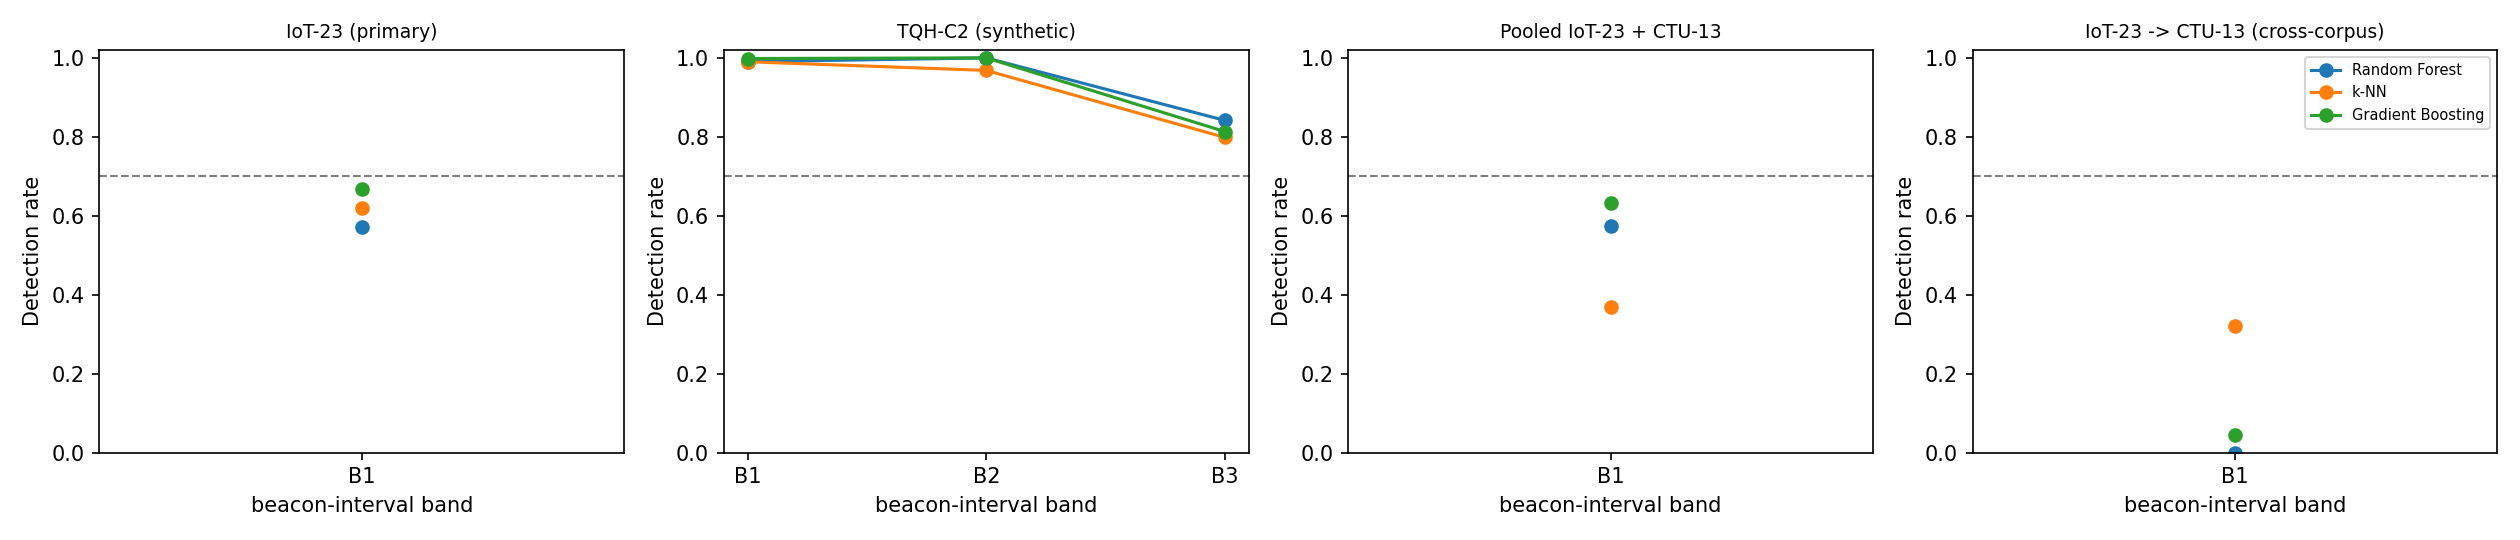

In [16]:
# Save benchmark results and figures
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

with open(os.path.join(OUTPUT_DIR, "benchmark_results.json"), "w") as f:
    json.dump(results, f, indent=2, default=float)

rows = [{"scope": s, "detector": m, "band": b,
         "DR": v["DR"], "DR_sd": v["DR_sd"], "FAR": v["FAR"],
         "P": v["P"], "F1": v["F1"], "n": v["n"], "n_pos": v["n_pos"]}
        for s, r in results.items() for m, bm in r.items() for b, v in bm.items()]
per_band_df = pd.DataFrame(rows)
per_band_df.to_csv(os.path.join(OUTPUT_DIR, "benchmark_per_band.csv"), index=False)
print("saved benchmark_results.json + benchmark_per_band.csv")
display(per_band_df.round(3))

nsc = len(results)
fig, axes = plt.subplots(1, nsc, figsize=(4.2 * nsc, 3.6), squeeze=False)
for ax, (scope, r) in zip(axes[0], results.items()):
    for m, bm in r.items():
        bs = [b for b in BAND_LABELS if b in bm and np.isfinite(bm[b]["DR"])]
        ax.plot(bs, [bm[b]["DR"] for b in bs], marker="o", label=m)
    ax.axhline(TAU, ls="--", c="grey", lw=1)
    ax.set_title(scope, fontsize=9); ax.set_ylim(0, 1.02)
    ax.set_ylabel("Detection rate"); ax.set_xlabel("beacon-interval band")
axes[0][-1].legend(fontsize=7)
fig.tight_layout()
fig_path = os.path.join(FIG_DIR, "detection_rate_by_band.png")
fig.savefig(fig_path, dpi=150); plt.close(fig)
print("saved", fig_path)
display(Image(fig_path))

## 9. SHAP explainability

Use SHAP on the Gradient Boosting model to examine feature attribution by interval band and compare native-corpus versus cross-corpus attribution.

The goal is to identify feature-level shifts associated with cross-corpus performance changes.

In [17]:
# SHAP attribution
try:
    import shap
    HAVE_SHAP = True
except ImportError:
    HAVE_SHAP = False
    print("shap not installed (pip install shap) -- explainability skipped")

MAX_SHAP_ROWS = 500
SHAP_MODEL = "gb"   # kind key into GRIDS / _make_model -- Gradient Boosting


def _tree_shap(model, Xt):
    """SHAP values for the positive class, shape (n, n_features).

    HistGradientBoostingClassifier's TreeExplainer already returns a single
    array relative to the positive class; this stays a one-liner but is kept
    as a function so a future swap to Random Forest (3-D per-class output)
    only needs a change here, not at every call site.
    """
    expl = shap.TreeExplainer(model)
    sv = np.asarray(expl.shap_values(Xt))
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    return sv


def _fit_final_gb(sub, seed=RANDOM_SEEDS[0]):
    """One grouped train/test split (same discipline as grouped_cv), fit
    Gradient Boosting on the training side only. Returns the fitted model,
    the transformer, and the transformed+raw test-side data."""
    Xall = sub[FEATURES].to_numpy(float)
    y = sub["y"].to_numpy()
    grp = sub["channel_id"].to_numpy()
    bnd = sub["band"].to_numpy()
    tr, te = next(GroupKFold(n_splits=N_FOLDS).split(Xall, y, groups=grp))
    assert not (set(grp[tr]) & set(grp[te])), "channel leakage"

    ct = _transformer()
    Xtr, Xte = ct.fit_transform(Xall[tr]), ct.transform(Xall[te])
    Xtr_r, ytr_r = _resample(Xtr, y[tr], seed)
    bp = _select_params(SHAP_MODEL, GRIDS["Gradient Boosting"][1], Xtr, y[tr], grp[tr], seed)
    model = _make_model(SHAP_MODEL, bp, seed).fit(Xtr_r, ytr_r)
    return model, ct, Xte, bnd[te]


def shap_per_band(sub, seed=RANDOM_SEEDS[0], max_rows=MAX_SHAP_ROWS):
    if not HAVE_SHAP:
        return None
    model, ct, Xte, bnd_te = _fit_final_gb(sub, seed)
    rng = np.random.default_rng(seed)
    out = {"features": FEATURES, "bands": {}}
    for b in BAND_LABELS:
        idx = np.flatnonzero(bnd_te == b)
        if idx.size == 0:
            continue
        if idx.size > max_rows:
            idx = rng.choice(idx, size=max_rows, replace=False)
        sv = _tree_shap(model, Xte[idx])
        out["bands"][b] = np.abs(sv).mean(axis=0).tolist()
        print(f"  SHAP per-band {b}: {idx.size} rows sampled")
    return out


def shap_cross_corpus(train_df, test_df, seed=RANDOM_SEEDS[0], max_rows=MAX_SHAP_ROWS,
                      train_name="iot23", test_name="ctu13"):
    """Same protocol as cross_corpus() above: train on train_df in full,
    but hold out one grouped slice of it for the 'native' SHAP comparison."""
    if not HAVE_SHAP:
        return None
    Xall = train_df[FEATURES].to_numpy(float)
    y = train_df["y"].to_numpy()
    grp = train_df["channel_id"].to_numpy()
    tr_inner, native_te = next(GroupKFold(n_splits=N_FOLDS).split(Xall, y, groups=grp))
    assert not (set(grp[tr_inner]) & set(grp[native_te])), "channel leakage"

    ct = _transformer()
    Xtr = ct.fit_transform(Xall[tr_inner])
    Xtr_r, ytr_r = _resample(Xtr, y[tr_inner], seed)
    bp = _select_params(SHAP_MODEL, GRIDS["Gradient Boosting"][1], Xtr, y[tr_inner], grp[tr_inner], seed)
    model = _make_model(SHAP_MODEL, bp, seed).fit(Xtr_r, ytr_r)

    rng = np.random.default_rng(seed)

    def _sample_shap(df, idx_pool):
        if idx_pool.size > max_rows:
            idx_pool = rng.choice(idx_pool, size=max_rows, replace=False)
        Xt = ct.transform(df[FEATURES].to_numpy(float)[idx_pool])
        return np.abs(_tree_shap(model, Xt)).mean(axis=0)

    native = _sample_shap(train_df, native_te)
    transfer = _sample_shap(test_df, np.arange(len(test_df)))

    return {"features": FEATURES, "train_corpus": train_name, "test_corpus": test_name,
           "native": native.tolist(), "transfer": transfer.tolist()}


shap_band_result = shap_cross_result = None
if HAVE_SHAP:
    widest_scope = feat[feat.dataset.isin(["iot23", "ctu13"])] if len(feat[feat.dataset == "ctu13"]) else feat[feat.dataset == "iot23"]
    if widest_scope["y"].nunique() == 2 and len(widest_scope) > 50:
        print("SHAP per-band (Gradient Boosting) ...")
        shap_band_result = shap_per_band(widest_scope)

    _tr, _te = feat[feat.dataset == "iot23"], feat[feat.dataset == "ctu13"]
    if len(_tr) > 50 and _te["y"].nunique() == 2 and len(_te) > 20:
        print("SHAP cross-corpus (IoT-23 -> CTU-13) ...")
        shap_cross_result = shap_cross_corpus(_tr, _te)
    else:
        print("[skip] SHAP cross-corpus: CTU-13 not usable (see cross-corpus skip message above)")

    with open(os.path.join(OUTPUT_DIR, "shap_results.json"), "w") as f:
        json.dump({"per_band": shap_band_result, "cross_corpus": shap_cross_result}, f, indent=2)
    print("saved shap_results.json")


SHAP per-band (Gradient Boosting) ...
  SHAP per-band B1: 500 rows sampled
  SHAP per-band B2: 274 rows sampled
  SHAP per-band B3: 87 rows sampled
SHAP cross-corpus (IoT-23 -> CTU-13) ...
saved shap_results.json


saved /Users/ador/c2_features_out/figures/shap_band.png


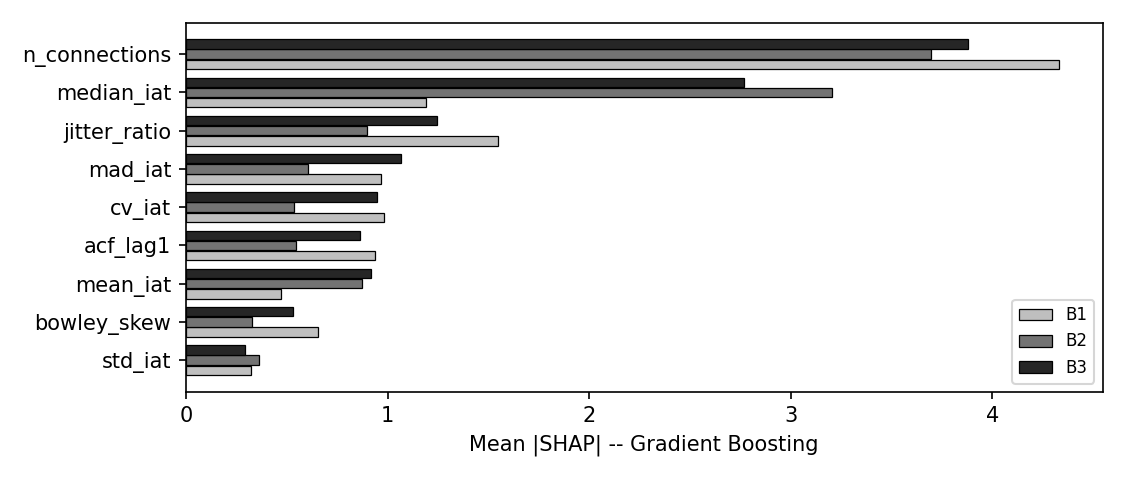

saved /Users/ador/c2_features_out/figures/shap_cross_corpus.png


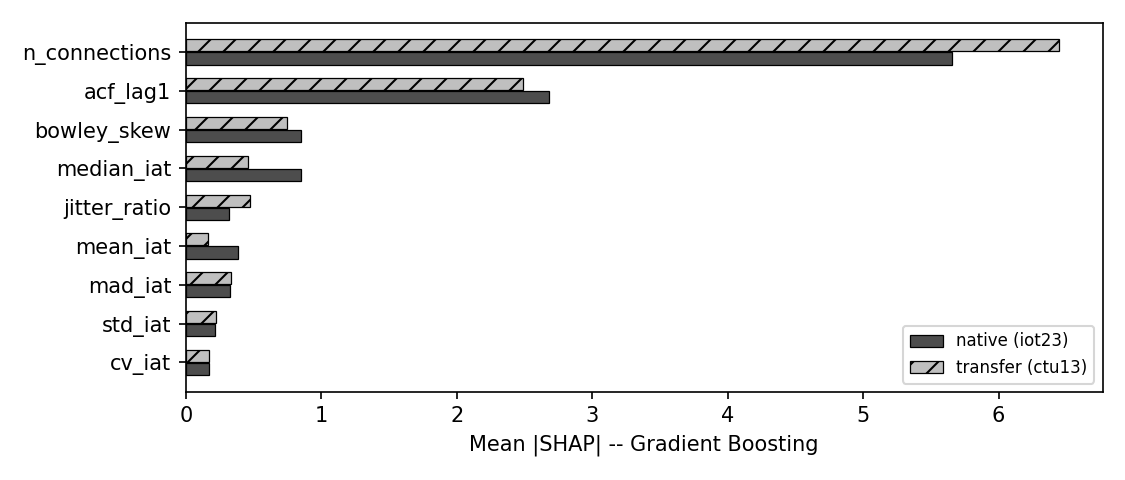

In [18]:
# SHAP figures
def _plot_shap_band(res, path, top=10):
    if not res or not res.get("bands"):
        print("no per-band SHAP result to plot"); return
    feats = res["features"]
    bands_present = [b for b in BAND_LABELS if b in res["bands"]]
    mat = np.array([res["bands"][b] for b in bands_present])
    order = np.argsort(mat.mean(axis=0))[-top:]
    names = [feats[i] for i in order]
    mat = mat[:, order]

    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    y = np.arange(len(names))
    w = 0.8 / len(bands_present)
    greys = {"B1": "0.75", "B2": "0.45", "B3": "0.15"}
    for i, b in enumerate(bands_present):
        off = (i - (len(bands_present) - 1) / 2) * w
        ax.barh(y + off, mat[i], height=w * 0.92, label=b, color=greys.get(b, "0.5"),
               edgecolor="black", linewidth=0.6)
    ax.set_yticks(y, names); ax.set_xlabel("Mean |SHAP| -- Gradient Boosting")
    ax.legend(fontsize=8); fig.tight_layout()
    fig.savefig(path, dpi=150); plt.close(fig)
    print("saved", path)


def _plot_shap_cross(res, path, top=10):
    if not res:
        print("no cross-corpus SHAP result to plot"); return
    feats = res["features"]
    native, transfer = np.array(res["native"]), np.array(res["transfer"])
    order = np.argsort(np.maximum(native, transfer))[-top:]
    names = [feats[i] for i in order]
    native, transfer = native[order], transfer[order]

    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    y = np.arange(len(names)); w = 0.34
    ax.barh(y - w / 2, native, height=w * 0.92, label=f"native ({res['train_corpus']})",
           color="0.30", edgecolor="black", linewidth=0.6)
    ax.barh(y + w / 2, transfer, height=w * 0.92, label=f"transfer ({res['test_corpus']})",
           color="0.75", edgecolor="black", linewidth=0.6, hatch="//")
    ax.set_yticks(y, names); ax.set_xlabel("Mean |SHAP| -- Gradient Boosting")
    ax.legend(fontsize=8); fig.tight_layout()
    fig.savefig(path, dpi=150); plt.close(fig)
    print("saved", path)


if shap_band_result is not None:
    p = os.path.join(FIG_DIR, "shap_band.png")
    _plot_shap_band(shap_band_result, p)
    display(Image(p))
if shap_cross_result is not None:
    p = os.path.join(FIG_DIR, "shap_cross_corpus.png")
    _plot_shap_cross(shap_cross_result, p)
    display(Image(p))


## 10. Bootstrap confidence intervals

Estimate uncertainty in the IoT-23 → CTU-13 cross-corpus DR/FAR/F1 gap using paired bootstrap resampling.

Use the same resampled test indices across detectors so detector comparisons remain paired.

In [19]:
# Paired bootstrap CI for cross-corpus metrics
N_BOOT = 2000
BOOT_SEED = 0

print("Re-fitting cross-corpus models to capture per-row scores for bootstrapping...")
cc_pred_boot = cross_corpus(tr, te)   # tr, te from section 8's cross-corpus scope

def _metric(y_true, y_pred, which):
    tp = int(((y_pred == 1) & (y_true == 1)).sum()); fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum()); fn = int(((y_pred == 0) & (y_true == 1)).sum())
    if which == "DR":  return tp / (tp + fn) if (tp + fn) else np.nan
    if which == "FAR": return fp / (fp + tn) if (fp + tn) else np.nan
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    return 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0


def bootstrap_ci(pred, band="B1", n_boot=N_BOOT, seed=BOOT_SEED, metric="DR"):
    """Paired bootstrap: same resampled row indices used for every detector on
    each replicate, so pairwise differences (e.g. RF - kNN) are valid paired
    comparisons, not independent-sample comparisons."""
    rng = np.random.default_rng(seed)
    models = list(pred.keys())

    # Aggregate seed probabilities per test row
    block, y_true_ref = {}, None
    for m in models:
        d = pred[m]
        mask = d["band"] == band
        yt, ys, sd = d["y_true"][mask], d["y_score"][mask], d["seed"][mask]
        seeds_u = np.unique(sd)
        score_blocks = [ys[sd == s] for s in seeds_u]
        yt_blocks    = [yt[sd == s] for s in seeds_u]
        n_test = len(score_blocks[0])
        assert all(len(b) == n_test for b in score_blocks), "seed blocks misaligned"
        avg_score = np.mean(np.vstack(score_blocks), axis=0)
        if y_true_ref is None:
            y_true_ref = yt_blocks[0]
        else:
            assert np.array_equal(y_true_ref, yt_blocks[0]), "test sets misaligned across models"
        block[m] = avg_score

    n = len(y_true_ref)
    boot_vals = {m: np.empty(n_boot) for m in models}
    for b in range(n_boot):
        bi = rng.integers(0, n, size=n)          # same indices for every model this replicate
        yt_b = y_true_ref[bi]
        for m in models:
            yp_b = (block[m][bi] >= 0.5).astype(int)
            boot_vals[m][b] = _metric(yt_b, yp_b, metric)

    point = {m: _metric(y_true_ref, (block[m] >= 0.5).astype(int), metric) for m in models}
    ci = {m: tuple(np.nanpercentile(boot_vals[m], [2.5, 97.5])) for m in models}

    pairs = {}
    for i in range(len(models)):
        for j in range(i + 1, len(models)):
            m1, m2 = models[i], models[j]
            diff = boot_vals[m1] - boot_vals[m2]
            lo, hi = np.nanpercentile(diff, [2.5, 97.5])
            pairs[f"{m1} - {m2}"] = dict(point=point[m1] - point[m2], ci=(float(lo), float(hi)),
                                         significant=bool(lo > 0 or hi < 0))
    return point, ci, pairs, n


for metric in ("DR", "FAR", "F1"):
    point, ci, pairs, n_test = bootstrap_ci(cc_pred_boot, band="B1", metric=metric)
    print(f"\n=== {metric}, band B1, IoT-23 -> CTU-13 (n_test={n_test}, {N_BOOT} bootstrap reps) ===")
    for m, p in point.items():
        lo, hi = ci[m]
        print(f"  {m:20s}  {metric}={p:.3f}   95% CI [{lo:.3f}, {hi:.3f}]")
    print(f"  --- pairwise differences ---")
    for pair, r in pairs.items():
        sig = "SIGNIFICANT" if r["significant"] else "not significant"
        print(f"  {pair:38s}  diff={r['point']:+.3f}   95% CI [{r['ci'][0]:+.3f}, {r['ci'][1]:+.3f}]   {sig}")


Re-fitting cross-corpus models to capture per-row scores for bootstrapping...

=== DR, band B1, IoT-23 -> CTU-13 (n_test=8103, 2000 bootstrap reps) ===
  Random Forest         DR=0.000   95% CI [0.000, 0.000]
  k-NN                  DR=0.320   95% CI [0.229, 0.409]
  Gradient Boosting     DR=0.039   95% CI [0.009, 0.079]
  --- pairwise differences ---
  Random Forest - k-NN                    diff=-0.320   95% CI [-0.409, -0.229]   SIGNIFICANT
  Random Forest - Gradient Boosting       diff=-0.039   95% CI [-0.079, -0.009]   SIGNIFICANT
  k-NN - Gradient Boosting                diff=+0.282   95% CI [+0.188, +0.372]   SIGNIFICANT

=== FAR, band B1, IoT-23 -> CTU-13 (n_test=8103, 2000 bootstrap reps) ===
  Random Forest         FAR=0.053   95% CI [0.049, 0.058]
  k-NN                  FAR=0.151   95% CI [0.144, 0.159]
  Gradient Boosting     FAR=0.091   95% CI [0.085, 0.098]
  --- pairwise differences ---
  Random Forest - k-NN                    diff=-0.098   95% CI [-0.107, -0.089]   SI